# Блок 3. Задача 1: Mean Shift

Цель: выполнить кластеризацию объектов датасета `Iris` без заранее заданного числа кластеров.

Используется алгоритм `MeanShift`.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")


## Загрузка и анализ данных


In [7]:
iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()
df_iris["target_name"] = df_iris["target"].map(dict(enumerate(iris.target_names)))
feature_cols = iris.feature_names

display(df_iris.head())
print("Размер датасета:", df_iris.shape)
print("Истинное распределение классов:")
print(df_iris["target_name"].value_counts())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Размер датасета: (150, 6)
Истинное распределение классов:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Подготовка данных


In [8]:
X = df_iris[feature_cols]
y_true = df_iris["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)


## Обучение модели


In [9]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=len(X_scaled))
model = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels = model.fit_predict(X_scaled)

print("Оцененная bandwidth:", round(bandwidth, 3))
print(pd.Series(labels).value_counts().sort_index())


Оцененная bandwidth: 1.207
0    92
1    50
2     8
Name: count, dtype: int64


## Метрики и визуализация


Количество кластеров: 3
Adjusted Rand Index: 0.56
Silhouette score: 0.433


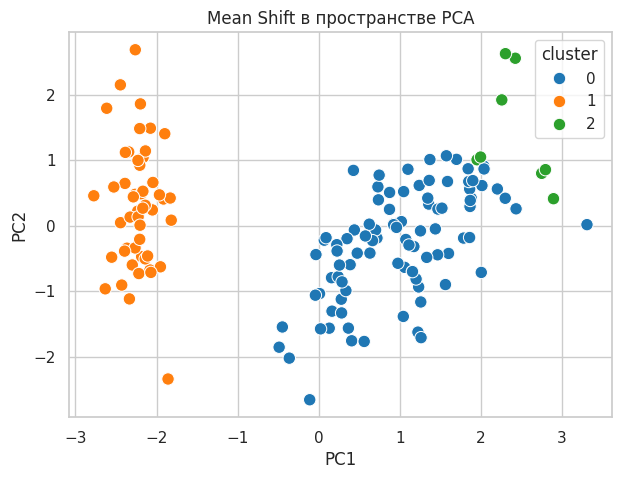

In [10]:
def evaluate_clusters(labels):
    unique_labels = set(labels)
    n_clusters = len(unique_labels - {-1})
    print("Количество кластеров:", n_clusters)
    print("Adjusted Rand Index:", round(adjusted_rand_score(y_true, labels), 3))
    if n_clusters > 1:
        mask = labels != -1
        print("Silhouette score:", round(silhouette_score(X_scaled[mask], labels[mask]), 3))

def plot_clusters(labels, title):
    plot_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "cluster": labels})
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=80)
    plt.title(title)
    plt.show()

evaluate_clusters(labels)
plot_clusters(labels, "Mean Shift в пространстве PCA")


## Вывод

Входные данные соответствуют задаче кластеризации: используется датасет `Iris` размером `150 x 6`, в кластеризацию передаются `4` числовых признака цветков, а `target` используется только для внешней оценки качества через `Adjusted Rand Index`. Истинные классы сбалансированы: по `50` объектов `setosa`, `versicolor` и `virginica`.

Mean Shift сам определил число кластеров при оценённом `bandwidth = 1.207`. По текущему запуску получены `3` кластера с размерами `92`, `50` и `8` объектов. Значения метрик: `Adjusted Rand Index = 0.560`, `Silhouette score = 0.433`.

Результат умеренный: алгоритм нашёл три кластера, но разбиение получилось несбалансированным, один кластер объединил большую часть объектов. Качество сильно зависит от выбранной ширины окна `bandwidth`, поэтому для Iris текущая настройка отделяет структуру данных только частично.
